In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Librerías cargadas ✅")

Librerías cargadas ✅


In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
df = pd.read_csv("saas-sales.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(9994, 19)
['Row ID', 'Order ID', 'Order Date', 'Date Key', 'Contact Name', 'Country', 'City', 'Region', 'Subregion', 'Customer', 'Customer ID', 'Industry', 'Segment', 'Product', 'License', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


In [5]:
print("Shape:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())

Shape: (9994, 19)

Tipos de datos:
Row ID            int64
Order ID            str
Order Date          str
Date Key          int64
Contact Name        str
Country             str
City                str
Region              str
Subregion           str
Customer            str
Customer ID       int64
Industry            str
Segment             str
Product             str
License             str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Valores nulos:
Row ID          0
Order ID        0
Order Date      0
Date Key        0
Contact Name    0
Country         0
City            0
Region          0
Subregion       0
Customer        0
Customer ID     0
Industry        0
Segment         0
Product         0
License         0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [6]:
# Convertir fecha
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extraer año y mes (útil para análisis temporal)
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M")

# Verificar
print("Rango de fechas:", df["Order Date"].min(), "→", df["Order Date"].max())
print("Años disponibles:", sorted(df["Year"].unique()))
print("Segmentos:", df["Segment"].unique())
print("Productos:", df["Product"].unique())

Rango de fechas: 2020-01-04 00:00:00 → 2023-12-31 00:00:00
Años disponibles: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]
Segmentos: <StringArray>
['SMB', 'Strategic', 'Enterprise']
Length: 3, dtype: str
Productos: <StringArray>
[           'Marketing Suite',                 'FinanceHub',
             'ContactMatcher',     'Marketing Suite - Gold',
        'SaaS Connector Pack',             'ChatBot Plugin',
             'Site Analytics',                    'OneView',
                    'Support',               'Data Smasher',
 'SaaS Connector Pack - Gold',                    'Storage',
            'Big Ol Database',                    'Alchemy']
Length: 14, dtype: str


In [7]:
# ── 1. Revenue y Profit total por año ──────────────────────────
yearly = df.groupby("Year").agg(
    Revenue=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
).reset_index()

yearly["Profit Margin %"] = (yearly["Profit"] / yearly["Revenue"] * 100).round(2)
print("=== Revenue & Profit por Año ===")
print(yearly.to_string(index=False))

# ── 2. Revenue por Segmento ────────────────────────────────────
print("\n=== Revenue por Segmento ===")
segmento = df.groupby("Segment").agg(
    Revenue=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Clientes=("Customer ID", "nunique")
).reset_index()
segmento["Profit Margin %"] = (segmento["Profit"] / segmento["Revenue"] * 100).round(2)
print(segmento.to_string(index=False))

# ── 3. Revenue por Producto ────────────────────────────────────
print("\n=== Top Productos por Revenue ===")
productos = df.groupby("Product").agg(
    Revenue=("Sales", "sum"),
    Profit=("Profit", "sum")
).reset_index()
productos["Profit Margin %"] = (productos["Profit"] / productos["Revenue"] * 100).round(2)
productos = productos.sort_values("Revenue", ascending=False)
print(productos.to_string(index=False))

=== Revenue & Profit por Año ===
 Year     Revenue     Profit  Orders  Profit Margin %
 2020 484247.4981 49543.9741     969            10.23
 2021 470532.5090 61618.6037    1038            13.10
 2022 608473.8300 81726.9308    1310            13.43
 2023 733947.0232 93507.5131    1692            12.74

=== Revenue por Segmento ===
   Segment      Revenue      Profit  Clientes  Profit Margin %
Enterprise  429653.1485  60298.6785        76            14.03
       SMB 1161401.3450 134119.2092        96            11.55
 Strategic  706146.3668  91979.1340        91            13.03

=== Top Productos por Revenue ===
                   Product     Revenue     Profit  Profit Margin %
            ContactMatcher 410378.2650 12496.2822             3.05
                FinanceHub 340935.4150 32136.4203             9.43
            Site Analytics 330007.0540 44515.7306            13.49
    Marketing Suite - Gold 223843.6080 21278.8264             9.51
           Big Ol Database 189238.6310  3384.

In [8]:
# ── LTV simplificado: revenue total por cliente ───────────────
ltv = df.groupby(["Customer ID", "Customer", "Segment"]).agg(
    LTV=("Sales", "sum"),
    Profit_Total=("Profit", "sum"),
    Ordenes=("Order ID", "nunique"),
    Primer_Compra=("Order Date", "min"),
    Ultima_Compra=("Order Date", "max")
).reset_index()

ltv["Ticket Promedio"] = (ltv["LTV"] / ltv["Ordenes"]).round(2)
ltv["Margen %"] = (ltv["Profit_Total"] / ltv["LTV"] * 100).round(2)

# Vida del cliente en días
ltv["Vida (días)"] = (ltv["Ultima_Compra"] - ltv["Primer_Compra"]).dt.days

print("=== Top 10 Clientes por LTV ===")
print(ltv.sort_values("LTV", ascending=False).head(10).to_string(index=False))

print("\n=== Ticket Promedio por Segmento ===")
print(ltv.groupby("Segment")["Ticket Promedio"].mean().round(2))

print("\n=== LTV Promedio por Segmento ===")
print(ltv.groupby("Segment")["LTV"].mean().round(2))

=== Top 10 Clientes por LTV ===
 Customer ID               Customer    Segment        LTV  Profit_Total  Ordenes Primer_Compra Ultima_Compra  Ticket Promedio  Margen %  Vida (días)
        1067 Mondelez International        SMB 30421.0678     8401.9155       52    2020-03-14    2023-12-29           585.02     27.62         1385
        1029                 Anthem        SMB 29258.5060     8109.4921       49    2020-01-14    2023-12-24           597.11     27.72         1440
        1007      AmerisourceBergen        SMB 25826.8460     1233.4395       44    2020-07-22    2023-12-25           586.97      4.78         1251
        1068         Morgan Stanley        SMB 25799.3600     -829.5184       50    2020-03-23    2023-12-31           515.99     -3.22         1378
        1002                  Aetna        SMB 25112.1010     3090.7710       64    2020-03-31    2023-12-10           392.38     12.31         1349
        1029                 Anthem Enterprise 25043.0500    -1980.7393   

In [9]:
# ── Impacto de descuentos en margen ───────────────────────────
bins = [0, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0]
labels = ["Sin descuento", "1-10%", "11-20%", "21-30%", "31-40%", "41-50%", "51%+"]

df["Descuento Rango"] = pd.cut(df["Discount"], 
                                bins=[-0.01, 0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0], 
                                labels=labels)

descuento_analisis = df.groupby("Descuento Rango", observed=True).agg(
    Transacciones=("Sales", "count"),
    Revenue=("Sales", "sum"),
    Profit=("Profit", "sum")
).reset_index()

descuento_analisis["Margen %"] = (descuento_analisis["Profit"] / descuento_analisis["Revenue"] * 100).round(2)
descuento_analisis["Revenue %"] = (descuento_analisis["Revenue"] / descuento_analisis["Revenue"].sum() * 100).round(2)

print("=== Impacto de Descuentos en Rentabilidad ===")
print(descuento_analisis.to_string(index=False))

=== Impacto de Descuentos en Rentabilidad ===
Descuento Rango  Transacciones      Revenue      Profit  Margen %  Revenue %
  Sin descuento           4798 1087908.4700 320987.6032     29.51      47.36
          1-10%             94   54369.3510   9029.1770     16.61       2.37
         11-20%           3709  792152.8895  91756.2975     11.58      34.48
         21-30%            227  103226.6550 -10369.2774    -10.05       4.49
         31-40%            233  130911.2428 -25448.1881    -19.44       5.70
         41-50%             77   64403.5140 -22999.5392    -35.71       2.80
           51%+            856   64228.7380 -76559.0513   -119.20       2.80


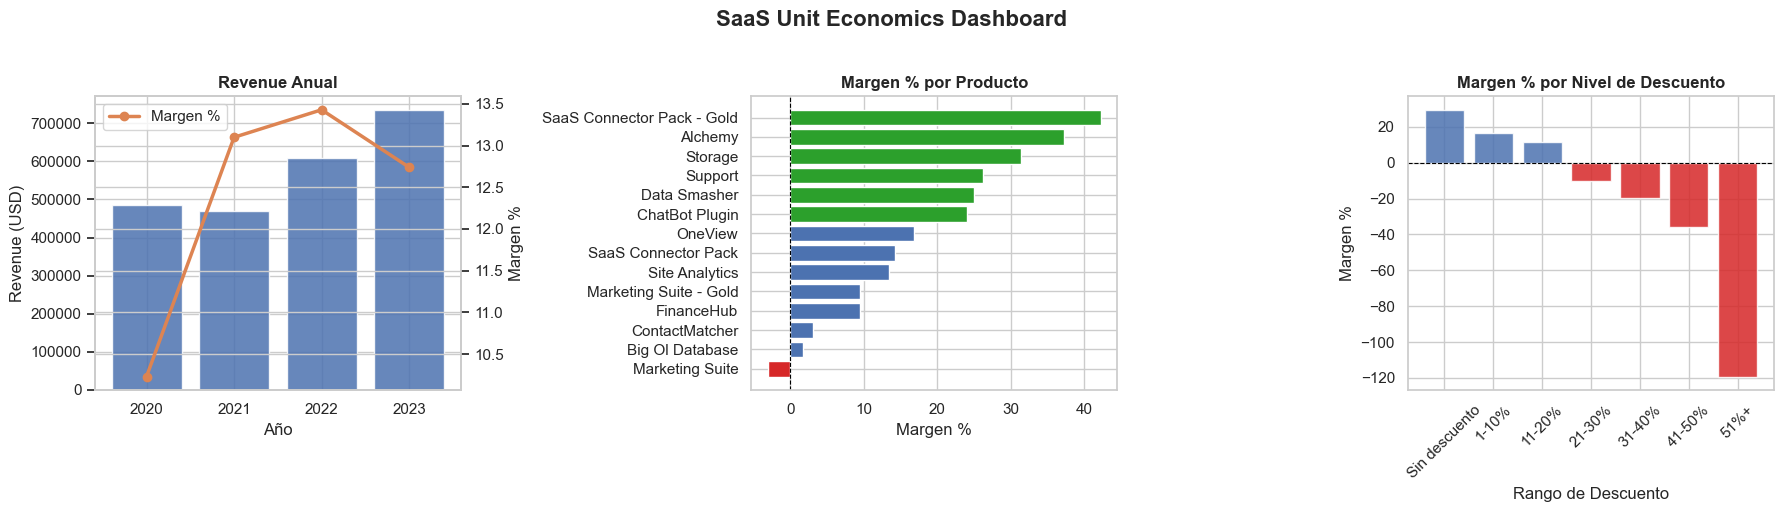

Gráfico guardado ✅


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SaaS Unit Economics Dashboard", fontsize=16, fontweight="bold", y=1.02)

# ── Gráfico 1: Revenue y Margen por Año ───────────────────────
ax1 = axes[0]
bars = ax1.bar(yearly["Year"], yearly["Revenue"], color="#4C72B0", alpha=0.85)
ax1.set_title("Revenue Anual", fontweight="bold")
ax1.set_xlabel("Año")
ax1.set_ylabel("Revenue (USD)")
ax2_twin = ax1.twinx()
ax2_twin.plot(yearly["Year"], yearly["Profit Margin %"], color="#DD8452", 
              marker="o", linewidth=2.5, label="Margen %")
ax2_twin.set_ylabel("Margen %")
ax2_twin.legend(loc="upper left")

# ── Gráfico 2: Margen % por Producto ──────────────────────────
ax2 = axes[1]
prod_sorted = productos.sort_values("Profit Margin %")
colores = ["#d62728" if x < 0 else "#2ca02c" if x > 20 else "#4C72B0" 
           for x in prod_sorted["Profit Margin %"]]
ax2.barh(prod_sorted["Product"], prod_sorted["Profit Margin %"], color=colores)
ax2.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("Margen % por Producto", fontweight="bold")
ax2.set_xlabel("Margen %")

# ── Gráfico 3: Impacto de Descuentos ──────────────────────────
ax3 = axes[2]
colores_desc = ["#d62728" if x < 0 else "#4C72B0" 
                for x in descuento_analisis["Margen %"]]
ax3.bar(descuento_analisis["Descuento Rango"], descuento_analisis["Margen %"], 
        color=colores_desc, alpha=0.85)
ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax3.set_title("Margen % por Nivel de Descuento", fontweight="bold")
ax3.set_xlabel("Rango de Descuento")
ax3.set_ylabel("Margen %")
ax3.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("unit_economics_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado ✅")

In [11]:
with pd.ExcelWriter("unit_economics_results.xlsx") as writer:
    yearly.to_excel(writer, sheet_name="Revenue por Año", index=False)
    segmento.to_excel(writer, sheet_name="Por Segmento", index=False)
    productos.to_excel(writer, sheet_name="Por Producto", index=False)
    descuento_analisis.to_excel(writer, sheet_name="Impacto Descuentos", index=False)
    ltv.sort_values("LTV", ascending=False).to_excel(writer, sheet_name="LTV Clientes", index=False)

print("Excel exportado ✅")

Excel exportado ✅
